C:\Users\hp\AppData\Local\Temp\ipykernel_21264\2157394411.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start='2024-01-01', periods=180*24, freq='H')
C:\Users\hp\AppData\Local\Temp\ipykernel_21264\2157394411.py:54: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


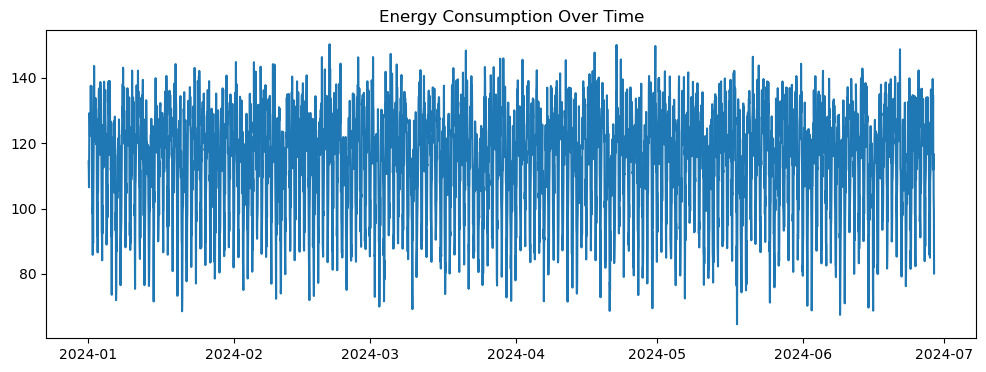

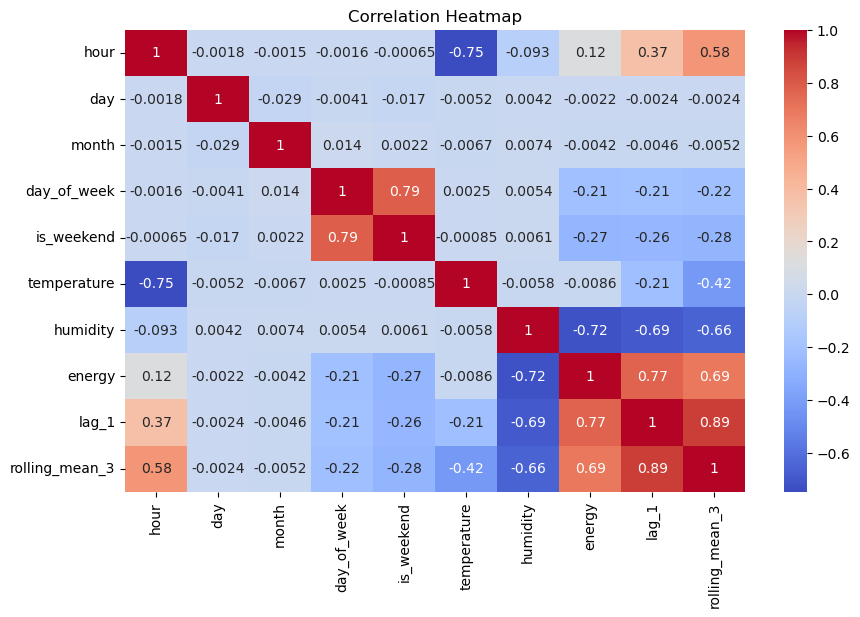

RMSE: 5.53
MAE: 4.45
R2: 0.878


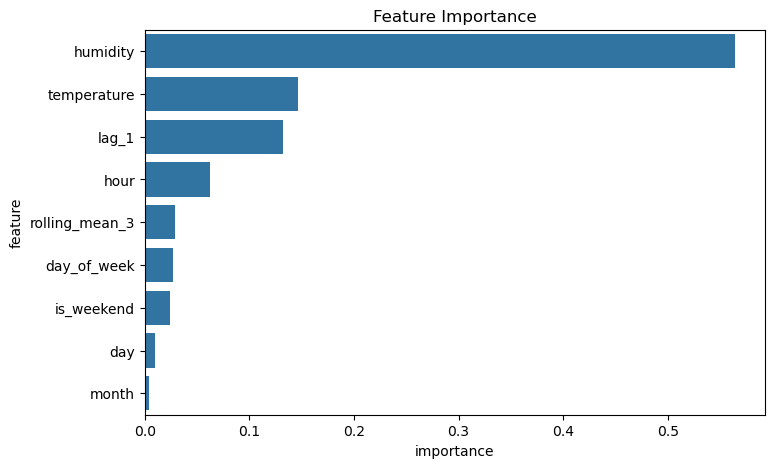

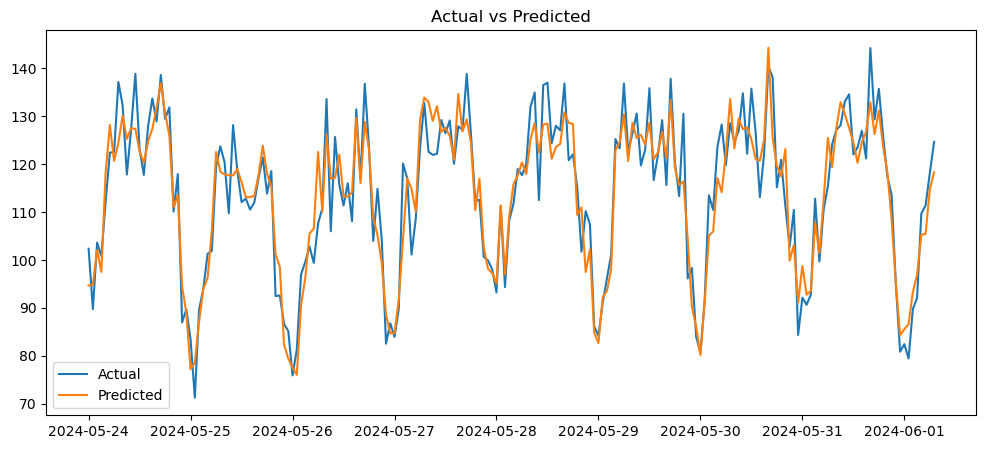

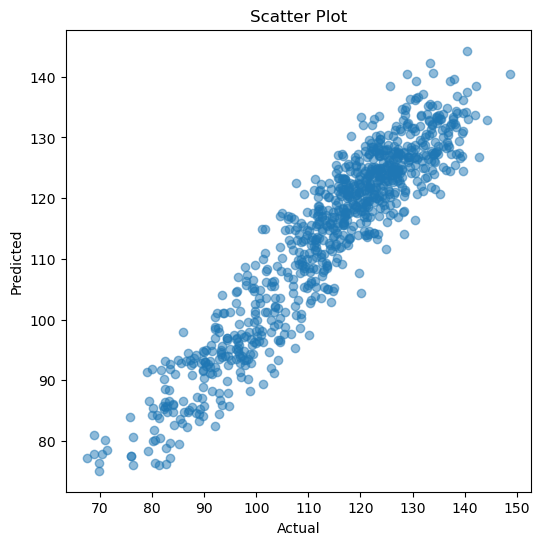

Project Completed Successfully!


In [3]:
# ==========================================
# AI-Powered Energy Consumption Forecasting
# ==========================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# -----------------------------
# 2. Generate Realistic Dataset
# -----------------------------
np.random.seed(42)

date_range = pd.date_range(start='2024-01-01', periods=180*24, freq='H')

df = pd.DataFrame()
df['datetime'] = date_range

# Time Features
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['day_of_week'] = df['datetime'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Weather Simulation
df['temperature'] = 25 + 10*np.sin(2*np.pi*df['hour']/24) + np.random.normal(0,2,len(df))
df['humidity'] = 60 + 20*np.cos(2*np.pi*df['hour']/24) + np.random.normal(0,5,len(df))

# Energy Consumption Logic
base = 100
hour_pattern = 20*np.sin(2*np.pi*(df['hour']-8)/24)
weekend_effect = -10 * df['is_weekend']
temp_effect = 2.5*np.abs(df['temperature'] - 22)
noise = np.random.normal(0,5,len(df))

df['energy'] = base + hour_pattern + weekend_effect + temp_effect + noise

# -----------------------------
# 3. Introduce Missing Values
# -----------------------------
for col in ['temperature', 'humidity']:
    idx = np.random.choice(df.index, size=50, replace=False)
    df.loc[idx, col] = np.nan

# -----------------------------
# 4. Data Cleaning
# -----------------------------
df.fillna(method='ffill', inplace=True)

# -----------------------------
# 5. Feature Engineering
# -----------------------------
df['lag_1'] = df['energy'].shift(1)
df['rolling_mean_3'] = df['energy'].shift(1).rolling(3).mean()

df.dropna(inplace=True)

# -----------------------------
# 6. Exploratory Data Analysis
# -----------------------------

# Energy Trend
plt.figure(figsize=(12,4))
plt.plot(df['datetime'], df['energy'])
plt.title("Energy Consumption Over Time")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns=['datetime']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# 7. Prepare Data
# -----------------------------
features = [
    'hour','day','month','day_of_week','is_weekend',
    'temperature','humidity','lag_1','rolling_mean_3'
]

X = df[features]
y = df['energy']

# Time-based split
split = int(len(df)*0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
dates_test = df['datetime'].iloc[split:]

# -----------------------------
# 8. Train Model
# -----------------------------
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# -----------------------------
# 9. Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# 10. Evaluation
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", round(rmse,2))
print("MAE:", round(mae,2))
print("R2:", round(r2,4))

# -----------------------------
# 11. Feature Importance
# -----------------------------
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance, x='importance', y='feature')
plt.title("Feature Importance")
plt.show()

# -----------------------------
# 12. Visualization
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(dates_test[:200], y_test.values[:200], label='Actual')
plt.plot(dates_test[:200], y_pred[:200], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

# Scatter Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Scatter Plot")
plt.show()

# -----------------------------
# 13. Save Output
# -----------------------------
pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
}).to_csv("predictions.csv", index=False)

print("Project Completed Successfully!")